In [28]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [29]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [30]:
print(aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors make up for it though!", "datacenters"))
sentiment = aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors make up for it though!", "datacenters")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'Negative': 0.9901864528656006, 'Neutral': 0.008432680740952492, 'Positive': 0.001380774425342679}
Negative 0.9901864528656006


In [31]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/brightdata_social_exports/instagram_datacenters_posts.json")

with file_path.open("r", encoding="utf-8") as f:
    instagram_posts = json.load(f)

In [32]:
total_length = 0
num_of_posts = len(instagram_posts)

for insta_post in instagram_posts:
    total_length += len(insta_post["description"])

print("Average post length:", total_length / num_of_posts)

Average post length: 842.0637788018433


In [33]:
'''
post_sentiments = []
post_sentiment_degrees = []

a = 0
for insta_post in instagram_posts:
    a += 1
    sentiment = aspect_sentiment(insta_post["description"], "datacenters")
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    print("Posts scanned:", a, end="\r")

'''

'\npost_sentiments = []\npost_sentiment_degrees = []\n\na = 0\nfor insta_post in instagram_posts:\n    a += 1\n    sentiment = aspect_sentiment(insta_post["description"], "datacenters")\n    post_sentiments.append(max(sentiment, key=sentiment.get))\n    post_sentiment_degrees.append(max(sentiment.values()))\n    print("Posts scanned:", a, end="\r")\n\n'

In [34]:
'''
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("instagram_sentiments_backup.json", "w") as f:
    json.dump(data, f)
'''

'\nsentiments_backup = post_sentiments.copy()\nsentiment_degrees_backup = post_sentiment_degrees.copy()\n\ndata = {\n    "sentiments": post_sentiments,\n    "sentiment_degrees": post_sentiment_degrees\n}\n\nwith open("instagram_sentiments_backup.json", "w") as f:\n    json.dump(data, f)\n'

In [35]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/brightdata_across_social_media_analysis/across_social_media_overall_sentiment_analysis/using_ABSA_CURRENT_TECHNIQUE/instagram_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)

post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]

In [36]:
posts = pd.DataFrame(columns=["ids", "text", "date", "upvotes", "number of comments", "subreddit", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_likes = []
post_comment_numbers = []
post_has_photos = []
post_has_videos = []
post_locations = []
post_user_followers = []
post_is_paid_partnership = []

a = 0

for insta_post in instagram_posts:
    a += 1

    post_ids.append(insta_post["post_id"])
    post_texts.append(insta_post["description"])
    post_dates.append(insta_post["date_posted"])

    if(insta_post["likes"] == None):
        post_likes.append(0)
    else:
        post_likes.append(insta_post["likes"])
    
    post_comment_numbers.append(insta_post["num_comments"])

    if(insta_post["photos"] == None):
        post_has_photos.append(False)
    else:
        post_has_photos.append(True)
    
    if(insta_post["videos"] == None):
        post_has_videos.append(False)
    else:
        post_has_videos.append(True)
    
    post_locations.append(insta_post["location"])

    if(insta_post["followers"] == None):
        post_user_followers.append(0)
    else:
        post_user_followers.append(insta_post["followers"])
    
    post_is_paid_partnership.append(insta_post["is_paid_partnership"])

    print("Posts scanned:", a, end="\r")


posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["likes"] = post_likes
posts["number of comments"] = post_comment_numbers
posts["has photos"] = post_has_photos
posts["has videos"] = post_has_videos
posts["location"] = post_locations
posts["followers"] = post_user_followers
posts["is paid partnership"] = post_is_paid_partnership
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

In [37]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "likes": "int64",
    "number of comments": "int64",
    "has photos": "bool",
    "has videos": "bool",
    "location": "string",
    "followers": "int64",
    "is paid partnership": "bool",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [38]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
posts_with_company.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,QTS,Vantage,CyrusOne,CoreSite,likes,has photos,has videos,location,followers,is paid partnership
0,3721327515874322375,A fault line is being carved in American socie...,2025-09-14T10:00:18.000Z,NaN,87,NaN,Negative,0.747797,False,False,...,False,False,False,False,8798,True,False,<NA>,1491305,False
1,3816868091562055636,1) Infrastructure and efficiency gains: Google...,2026-01-24T03:42:44.000Z,NaN,0,NaN,Positive,0.793315,False,False,...,False,False,False,False,0,True,False,<NA>,22,False
4,3514736805808571036,New AI-designed carbon-removal material to be ...,2024-12-03T07:01:41.000Z,NaN,0,NaN,Neutral,0.988341,False,True,...,False,False,False,False,0,True,False,<NA>,10746,False
10,3598302896928712114,Is Data Centre gonna be the next big thing in ...,2025-03-28T14:12:35.000Z,NaN,1,NaN,Neutral,0.988383,False,False,...,False,False,False,False,517,True,False,<NA>,19091,False
20,3763915258096812122,A major investment for India's digital future!...,2025-11-12T02:14:45.000Z,NaN,6,NaN,Positive,0.638074,False,False,...,False,False,False,False,0,True,False,<NA>,592550,False


In [39]:
def remove_links(text):
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

posts["text"] = posts["text"].apply(remove_links)

In [40]:
len(posts)
posts.head()

,ids,text,date,upvotes,number of comments,subreddit,sentiment,degree,AWS,Amazon,...,QTS,Vantage,CyrusOne,CoreSite,likes,has photos,has videos,location,followers,is paid partnership
0,3721327515874322375,A fault line is being carved in American socie...,2025-09-14T10:00:18.000Z,NaN,87,NaN,Negative,0.747797,False,False,...,False,False,False,False,8798,True,False,<NA>,1491305,False
1,3816868091562055636,1) Infrastructure and efficiency gains: Google...,2026-01-24T03:42:44.000Z,NaN,0,NaN,Positive,0.793315,False,False,...,False,False,False,False,0,True,False,<NA>,22,False
2,3728811688410047717,✅ Mission accomplished!\n\nThe LORCO Data team...,2025-09-24T15:50:13.000Z,NaN,0,NaN,Positive,0.762429,False,False,...,False,False,False,False,4,True,False,"['Orlando', 'Florida']",20,False
3,3480520001695649979,"NEXTDC pays $353m for Western Sydney site, lay...",2024-10-17T01:58:59.000Z,NaN,0,NaN,Neutral,0.606226,False,False,...,False,False,False,False,8,True,False,<NA>,18118,False
4,3514736805808571036,New AI-designed carbon-removal material to be ...,2024-12-03T07:01:41.000Z,NaN,0,NaN,Neutral,0.988341,False,True,...,False,False,False,False,0,True,False,<NA>,10746,False


In [41]:
print(posts.columns)

Index(['ids', 'text', 'date', 'upvotes', 'number of comments', 'subreddit',
       'sentiment', 'degree', 'AWS', 'Amazon', 'Google', 'Microsoft', 'Azure',
       'Meta', 'Oracle', 'Equinix', 'Digital Realty', 'IBM', 'Facebook',
       'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite', 'likes',
       'has photos', 'has videos', 'location', 'followers',
       'is paid partnership'],
      dtype='object')


In [42]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "Positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "Negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for all of instagram: ", (pos-neg)/total)

Average sentiment for all of instagram:  0.3337082128996067


In [43]:
pos = posts.loc[posts["sentiment"] == "Positive"]
neg = posts.loc[posts["sentiment"] == "Negative"]
neutral = posts.loc[posts["sentiment"] == "Neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.4780645161290323
Percent of posts that are negative: 0.09419354838709677
Percent of posts that are positive: 0.42774193548387096
Percent of negative posts that are really negative: 0.21966731898238748
Percent of positive posts that are really positive: 0.1887524240465417


In [ ]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "Positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "Negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for instagram posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))

Number of posts from 2010:  0
Number of posts from 2011:  0
Number of posts from 2012:  1
Number of posts from 2013:  7
Average sentiment for instagram posts from 2013:  0.6010319552749323
Number of posts from 2014:  4
Average sentiment for instagram posts from 2014:  0.05123508690036673
Number of posts from 2015:  5
Average sentiment for instagram posts from 2015:  0.37561887126367
Number of posts from 2016:  47
Average sentiment for instagram posts from 2016:  0.05755027655952095
Number of posts from 2017:  12
Average sentiment for instagram posts from 2017:  0.40000221247476775
Number of posts from 2018:  43
Average sentiment for instagram posts from 2018:  0.2751862703718961
Number of posts from 2019:  47
Average sentiment for instagram posts from 2019:  0.39855603905787035
Number of posts from 2020:  107
Average sentiment for instagram posts from 2020:  0.4065209709198752
Number of posts from 2021:  157
Average sentiment for instagram posts from 2021:  0.23622448722162132
Number o

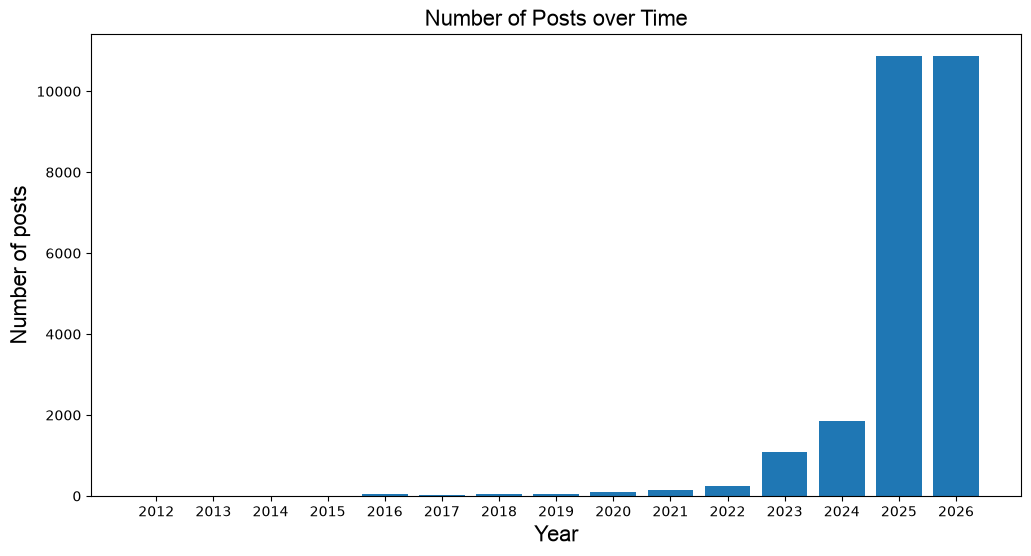

In [49]:
categories = ["2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024]), len(year_datasets[2025]), len(year_datasets[2025])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)
plt.show()

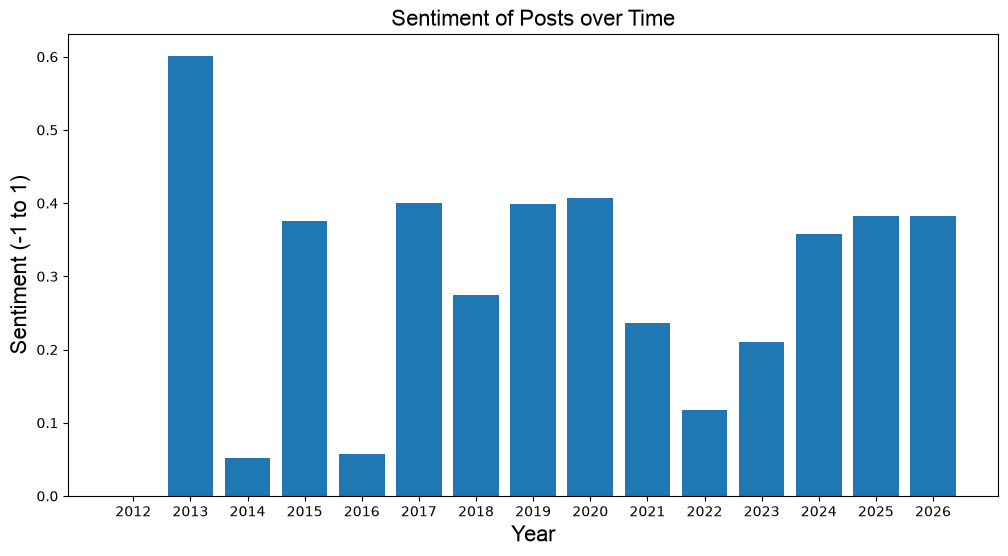

In [50]:
categories = ["2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024]), avg_sentiment_calculation(year_datasets[2025]), avg_sentiment_calculation(year_datasets[2025])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [47]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts: 1487
Average sentiment of AWS-related posts: 0.2969811135048034
Number of Google-related posts: 1899
Average sentiment of Google-related posts: 0.3861354353313857
Number of Microsoft-related posts: 1416
Average sentiment of Microsoft-related posts: 0.40517745045313136
Number of Meta-related posts: 1171
Average sentiment of Meta-related posts: 0.40432933271233834
Number of Oracle-related posts: 357
Average sentiment of Oracle-related posts: 0.40675429232037275
Number of Equinix-related posts: 85
Average sentiment of Equinix-related posts: 0.563849921906077
Number of Digital Realty-related posts: 36
Average sentiment of Digital Realty-related posts: 0.36857697575461057
Number of IBM-related posts: 95
Average sentiment of IBM-related posts: 0.4219837442405692
Number of Apple-related posts: 304
Average sentiment of Apple-related posts: 0.43442429019594103
Number of QTS-related posts: 20
Average sentiment of QTS-related posts: 0.1411664774174511
Number of Van

In [48]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["likes"] >= min]
    non_viral_posts = posts.loc[posts["likes"] < min]
    print("What's considered viral: posts with over", min, "likes")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))

analysis_of_viral_posts(1000)
print("\n")
analysis_of_viral_posts(5000)
print("\n")
analysis_of_viral_posts(10000)

What's considered viral: posts with over 1000 likes
Number of viral posts: 2448
Average sentiment of viral posts: 0.1942539487042909
Average sentiment of non-viral posts: 0.35105060400349697
Amount percent of viral posts that are polar (degree) > 0.90:  0.22099673202614378
Percent of viral posts that are negative:  0.16830065359477125
Percent of non-viral posts that are negative:  0.08477041346353625


What's considered viral: posts with over 5000 likes
Number of viral posts: 893
Average sentiment of viral posts: 0.14750278166263556
Average sentiment of non-viral posts: 0.3417250801494698
Amount percent of viral posts that are polar (degree) > 0.90:  0.2620380739081747
Percent of viral posts that are negative:  0.18477043673012317
Percent of non-viral posts that are negative:  0.09030614696976978


What's considered viral: posts with over 10000 likes
Number of viral posts: 493
Average sentiment of viral posts: 0.11386520457131949
Average sentiment of non-viral posts: 0.3388604191822122